<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 153.0 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 107.6 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-05-18 05:32:06--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  50.2MB/s    in 3.0s    

2026-05-18 05:32:09 (50.2 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



72         7322.0
374       30074.0
379       91295.0
385       53703.0
389      110000.0
           ...   
41180     44640.0
41184    170000.0
41185    116844.0
41186     12000.0
41187    222834.0
Name: ConvertedCompYearly, Length: 23286, dtype: float64


<Axes: ylabel='Frequency'>

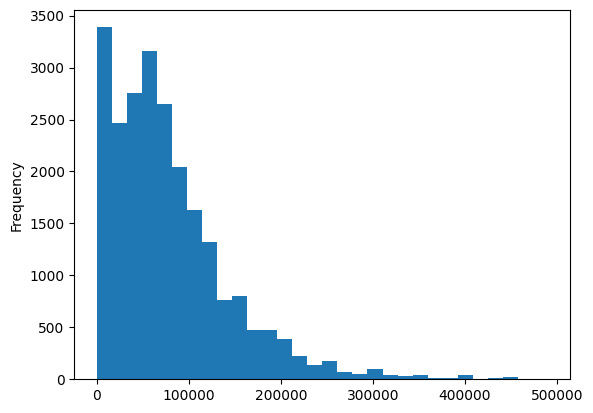

In [28]:
## Write your code here
con = df['ConvertedCompYearly'].dropna()
conn = con[(con>0) & (con<500000)]
conn.plot(kind='hist',bins =30)
#plt.title('Distribution of year compensation')
#plt.show()
          

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64


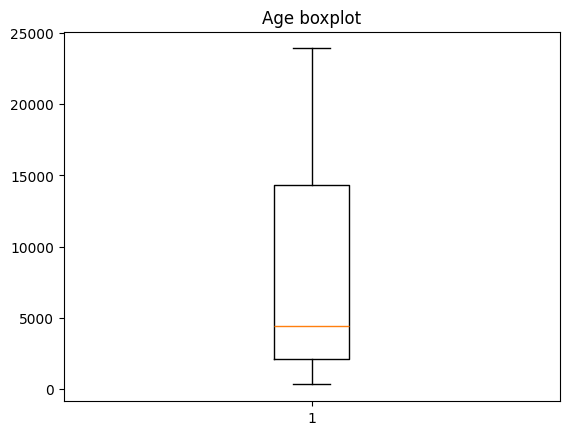

In [31]:
## Write your code here
dfb = df['Age'].dropna().value_counts()
print (dfb)
plt.boxplot(dfb)
plt.title('Age boxplot')
plt.show()


### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



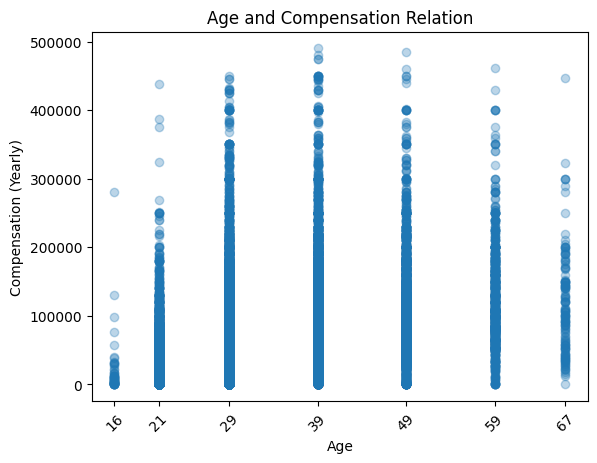

In [41]:
## Write your code here
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 67,
    'Prefer not to say': None
}

dfs = df[['Age', 'ConvertedCompYearly']].dropna()
dfs['Age'] = dfs['Age'].map(age_map)  # replace strings with numbers
dfs = dfs.dropna()  # drop 'Prefer not to say' (mapped to None)

dfcon = dfs[(dfs['ConvertedCompYearly'] > 0) & (dfs['ConvertedCompYearly'] < 500000)]

plt.scatter(x=dfcon['Age'], y=dfcon['ConvertedCompYearly'], marker='o', alpha=0.3)
plt.xticks(list(age_map.values())[:-1], rotation=45)  # show midpoints on x axis
plt.xlabel('Age')
plt.ylabel('Compensation (Yearly)')
plt.title('Age and Compensation Relation')
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


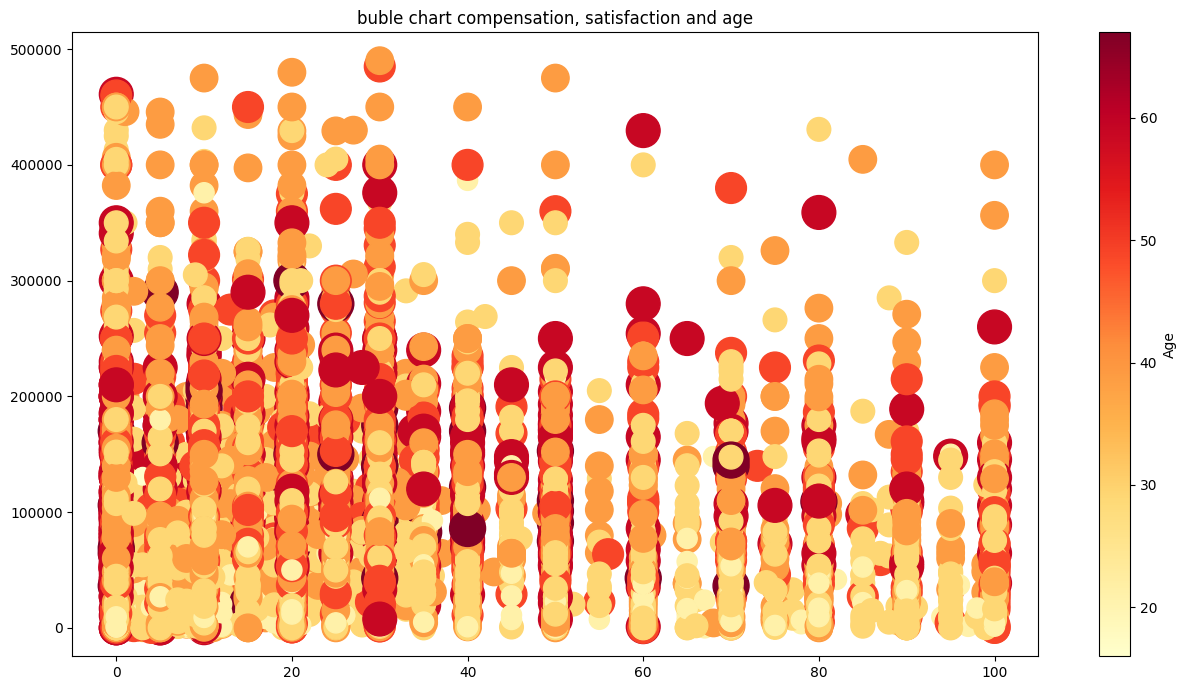

In [50]:
## Write your code here
dfsj = df[['Age', 'ConvertedCompYearly','JobSatPoints_6']].dropna()
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 67,
    'Prefer not to say': None
}

dfsj = dfsj[(dfsj['ConvertedCompYearly'] > 0) & (dfsj['ConvertedCompYearly'] < 500000)]
dfsj['Age'] = dfsj['Age'].map(age_map)  # replace strings with numbers
dfsj = dfsj.dropna()
plt.figure(figsize=(13,7))
sc = plt.scatter(x=dfsj['JobSatPoints_6'],y=dfsj['ConvertedCompYearly'],s=dfsj['Age']*10,c=dfsj['Age'],cmap='YlOrRd')
plt.colorbar(sc,label='Age')
plt.title('buble chart compensation, satisfaction and age')
plt.tight_layout()
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64


Text(0.5, 1.0, 'Mainbranch distribution')

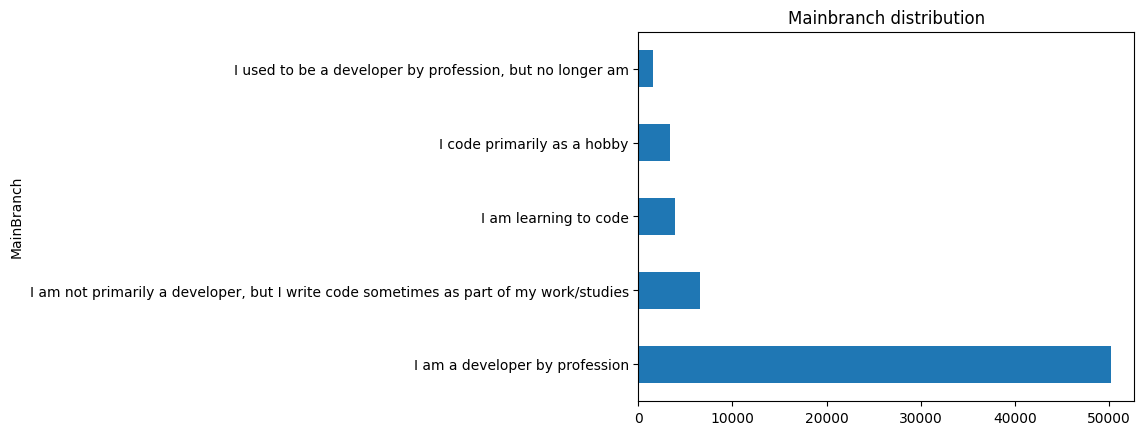

In [56]:
## Write your code here
dfm = df['MainBranch'].dropna().value_counts()
print(dfm)

dfm.plot(kind='barh' )
plt.title('Mainbranch distribution')

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



LanguageWantToWorkWith
Python        25047
JavaScript    23774
SQL           22400
HTML/CSS      20721
TypeScript    20239
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 5 Programming Languages Respondents')

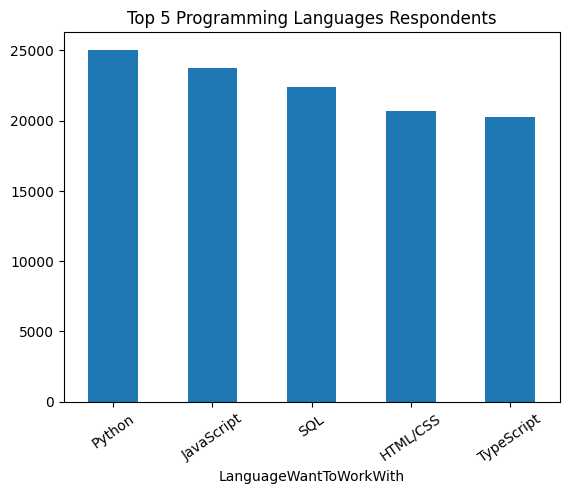

In [74]:
## Write your code here
dfl= df['LanguageWantToWorkWith'].dropna()
df2 = dfl.str.split(';').explode().str.strip()

df3 = df2.value_counts().head()
print (df3)
df3.plot(kind='bar',rot = 35)
plt.title('Top 5 Programming Languages Respondents')

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


Text(0.5, 1.0, 'job satisfaction by Age')

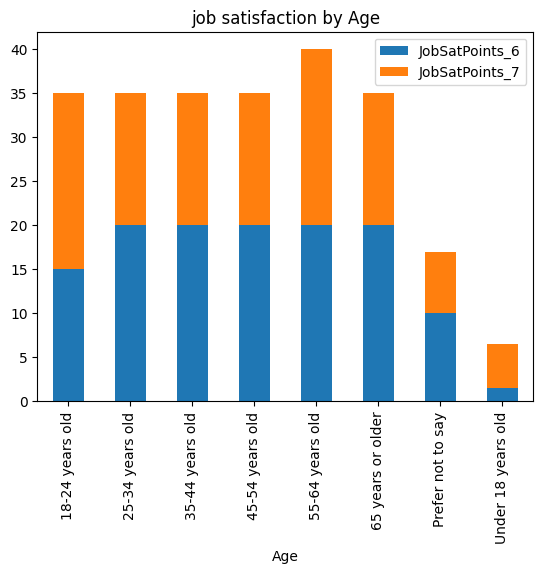

In [79]:
## Write your code here
sb = df[['Age','JobSatPoints_6', 'JobSatPoints_7']].dropna()
dfsb =sb.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
dfsb.plot.bar(stacked=True)
plt.title('job satisfaction by Age')

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 5 Programming Languages Respondents')

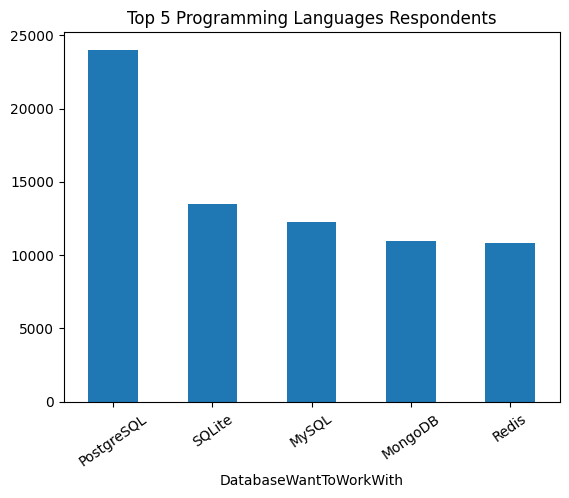

In [80]:
## Write your code here
dfd= df['DatabaseWantToWorkWith'].dropna()
dfd1 = dfd.str.split(';').explode().str.strip()

dfd2 = dfd1.value_counts().head()
print (dfd2)
dfd2.plot(kind='bar',rot = 35)
plt.title('Top 5 Programming Languages Respondents')

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



Text(0.5, 1.0, 'job satisfaction by Age')

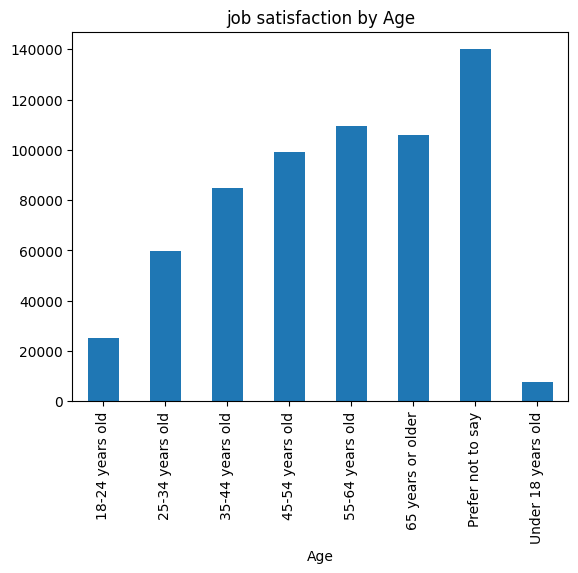

In [81]:
## Write your code here
sc = df[['Age','ConvertedCompYearly']].dropna()
dfsc =sc.groupby('Age')['ConvertedCompYearly'].median()
dfsc.plot.bar(stacked=True)
plt.title('job satisfaction by Age')

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



Country
USA            11095
Germany         4947
India           4231
UK and NI       3224
Ukraine         2672
France          2110
Canada          2104
Poland          1534
Netherlands     1449
Brazil          1375
Name: count, dtype: int64


<Axes: title={'center': 'Count by country'}, xlabel='Country'>

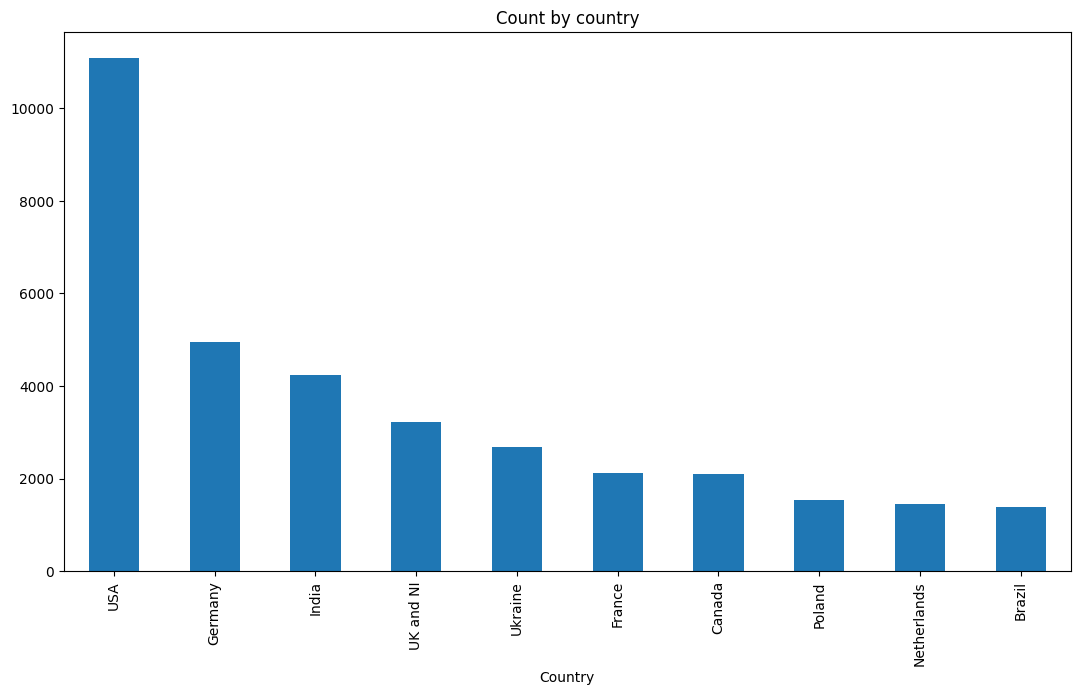

In [94]:
## Write your code here
cn =df['Country'].replace({'United States of America': 'USA','United Kingdom of Great Britain and Northern Ireland': 'UK and NI'})
cn = cn.dropna().value_counts().head(10)
print(cn)
plt.figure(figsize=(13,7))
cn.plot(kind='bar',title= 'Count by country')

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
